In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [135]:
df = sns.load_dataset("titanic")


In [136]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [137]:
df.shape

(891, 15)

In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [139]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [140]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [141]:
df.duplicated().sum()

np.int64(107)

In [142]:
df = df.drop_duplicates()
df.drop(columns=['embark_town','class','alive','deck','who','alone'], inplace= True, errors = 'ignore')

In [143]:
median = df["age"].median()
df["age"] = df["age"].fillna(median)
print (df ["age"].isnull().sum())

0


In [144]:
mode = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(mode)
print (df ["embarked"].isnull().sum())

0


In [145]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
dtype: int64

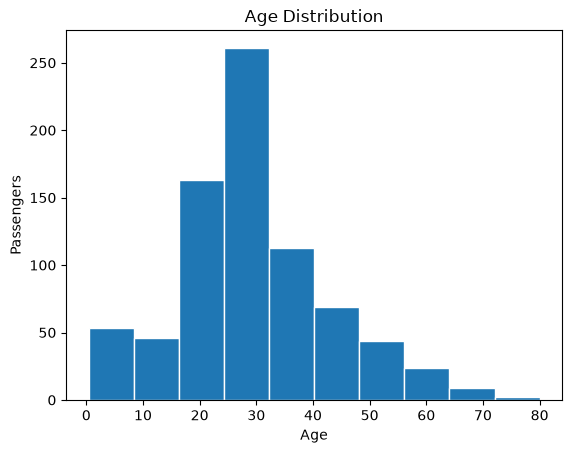

In [146]:
plt.hist(df["age"], edgecolor = 'white')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passengers")
plt.show()

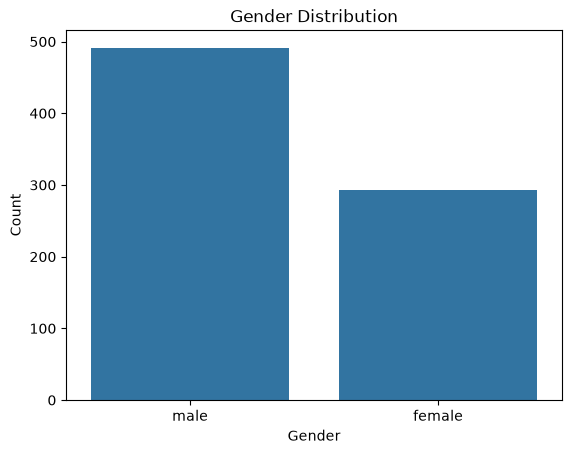

In [147]:
sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

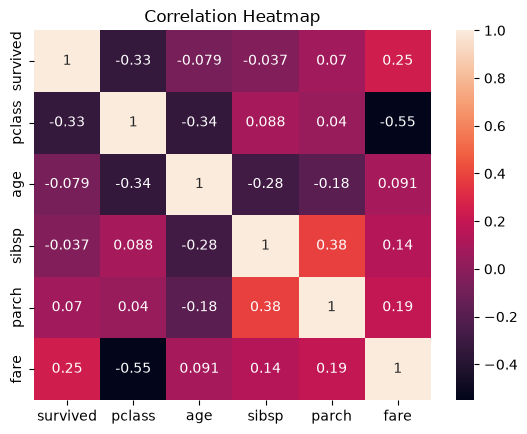

In [148]:
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True)

plt.title("Correlation Heatmap")

plt.show()

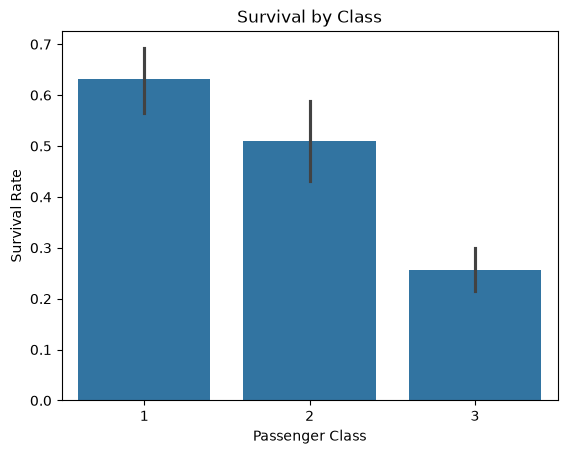

In [149]:
sns.barplot(x="pclass",
            y="survived",
            data=df)

plt.title("Survival by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [150]:
df["family_size"] = (
    df["sibsp"] +
    df["parch"] + 1
)



In [151]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,family_size
0,0,3,male,22.0,1,0,7.2500,S,True,2
1,1,1,female,38.0,1,0,71.2833,C,False,2
2,1,3,female,26.0,0,0,7.9250,S,False,1
3,1,1,female,35.0,1,0,53.1000,S,False,2
4,0,3,male,35.0,0,0,8.0500,S,True,1


In [152]:
df["is_alone"] = (
    df["family_size"] == 1
).astype(int)


In [153]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,True,2,0
1,1,1,female,38.0,1,0,71.2833,C,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,False,1,1
3,1,1,female,35.0,1,0,53.1000,S,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,True,1,1


In [154]:
df["fare_per_person"] = (
    df["fare"] /
    df["family_size"]
)


In [155]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,family_size,is_alone,fare_per_person
0,0,3,male,22.0,1,0,7.2500,S,True,2,0,3.62500
1,1,1,female,38.0,1,0,71.2833,C,False,2,0,35.64165
2,1,3,female,26.0,0,0,7.9250,S,False,1,1,7.92500
3,1,1,female,35.0,1,0,53.1000,S,False,2,0,26.55000
4,0,3,male,35.0,0,0,8.0500,S,True,1,1,8.05000


In [156]:
# Save cleaned dataset
df.to_csv("titanic_clean.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [157]:
df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   sex              784 non-null    str    
 3   age              784 non-null    float64
 4   sibsp            784 non-null    int64  
 5   parch            784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         784 non-null    str    
 8   adult_male       784 non-null    bool   
 9   family_size      784 non-null    int64  
 10  is_alone         784 non-null    int64  
 11  fare_per_person  784 non-null    float64
dtypes: bool(1), float64(3), int64(6), str(2)
memory usage: 74.3 KB


In [158]:
df = pd.get_dummies(df, columns=['sex','embarked','adult_male'], dtype=int)

In [159]:
df.head()

,survived,pclass,age,sibsp,parch,fare,family_size,is_alone,fare_per_person,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,adult_male_False,adult_male_True
0,0,3,22.0,1,0,7.2500,2,0,3.62500,0,1,0,0,1,0,1
1,1,1,38.0,1,0,71.2833,2,0,35.64165,1,0,1,0,0,1,0
2,1,3,26.0,0,0,7.9250,1,1,7.92500,1,0,0,0,1,1,0
3,1,1,35.0,1,0,53.1000,2,0,26.55000,1,0,0,0,1,1,0
4,0,3,35.0,0,0,8.0500,1,1,8.05000,0,1,0,0,1,0,1


In [160]:
df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   survived          784 non-null    int64  
 1   pclass            784 non-null    int64  
 2   age               784 non-null    float64
 3   sibsp             784 non-null    int64  
 4   parch             784 non-null    int64  
 5   fare              784 non-null    float64
 6   family_size       784 non-null    int64  
 7   is_alone          784 non-null    int64  
 8   fare_per_person   784 non-null    float64
 9   sex_female        784 non-null    int64  
 10  sex_male          784 non-null    int64  
 11  embarked_C        784 non-null    int64  
 12  embarked_Q        784 non-null    int64  
 13  embarked_S        784 non-null    int64  
 14  adult_male_False  784 non-null    int64  
 15  adult_male_True   784 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 104.1 KB


In [161]:
print("Before:")
print("891 rows | 107 duplicates | 866 nulls | 15 columns")

print("After:")
print("784 rows | 0 duplicates | 0 nulls | 12 columns, +3 new features (family_size, is_alone, fare_per_person)")

Before:
891 rows | 107 duplicates | 866 nulls | 15 columns
After:
784 rows | 0 duplicates | 0 nulls | 12 columns, +3 new features (family_size, is_alone, fare_per_person)


In [162]:
print(df.columns.tolist())

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'adult_male_False', 'adult_male_True']


In [163]:
X = df[['pclass',
        'age',
        'sibsp',
        'parch',
        'fare',
        'family_size',
        'is_alone',
        'fare_per_person',
        'sex_male',
        'embarked_C',
        'embarked_Q',
        'embarked_S',
        'adult_male_True']]

y = df['survived']

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [165]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [166]:
model = LogisticRegression(
    max_iter=2000,
    C=1,
    solver='liblinear'
)

In [167]:
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty 

In [168]:
y_pred = model.predict(X_test)

In [179]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 85.99 %


In [178]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        92
           1       0.83      0.83      0.83        65

    accuracy                           0.86       157
   macro avg       0.86      0.86      0.86       157
weighted avg       0.86      0.86      0.86       157



In [172]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[81 11]
 [11 54]]


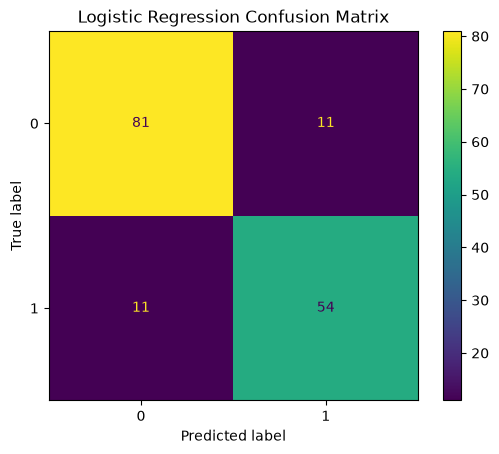

In [173]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [174]:
y_pred = model.predict(X_test)

In [175]:
feature_names = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',
    'family_size',
    'is_alone',
    'fare_per_person',
    'sex_male',
    'embarked_C',
    'embarked_Q',
    'embarked_S',
    'adult_male_True'
]

coefficients = model.coef_[0]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

            Feature  Coefficient
4              fare     0.095514
9        embarked_C     0.071787
11       embarked_S    -0.022438
7   fare_per_person    -0.035008
10       embarked_Q    -0.072735
8          sex_male    -0.128227
3             parch    -0.142928
6          is_alone    -0.239862
5       family_size    -0.271341
2             sibsp    -0.295376
1               age    -0.328424
0            pclass    -0.862110
12  adult_male_True    -1.182026
